In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2026-03-01 23:47:37.038748


# Project reporter dual-positive signature to scRNA-seq reference

Here we take the signature of 10 genes DE by the dual-positive neurons compared to all other neurons and project it onto a reference (https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE139088). These are identified in [02_marker-genes.ipynb](02_marker-genes.ipynb).

**Pinned Environment:** [`envs/sc-scvi.yaml`](../../envs/sc-scvi.yaml)

In [ ]:
from pathlib import Path
import os
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import sys

In [3]:
plt.rcParams['figure.figsize'] = (3, 3)
plt.rcParams['figure.dpi'] = 150

### Setup

In [ ]:
sys.path.append(str(Path.cwd().resolve().parents[1]))

from config.paths import BASE_DIR

# Output directories
output_dir = BASE_DIR / "figures"
output_dir.mkdir(parents=True, exist_ok=True)

plot_out_dir = output_dir / "plots"
plot_out_dir.mkdir(parents=True, exist_ok=True)

# Data input paths

# ginty reference
adata_ref_path = BASE_DIR / "data" / "scrna-seq" / "h5ad" / "04_clustered" /"GSE139088-scvi-leiden.h5ad"

### Load

In [ ]:
# reference
adata = sc.read_h5ad(adata_ref_path)

In [ ]:
# palette
import pickle
with open(os.path.join(output_dir, 'neuron_label_palette_mapped_ginty.pkl'), 'rb') as f:
    neuron_label_palette_mapped_ginty = pickle.load(f)

### Reference plots

In [ ]:
 # Reset adata.X to log1p
adata.X = adata.layers['log1p'].copy()

In [ ]:
## Score a dual-positive signature

# --- 1. Define your gene list ---
dual_signature_genes = [
    "Chrna3", "Cartpt", "Hpse", "Htr3b", "Mrap2",
    "Htr3a", "Mgat5b", "Chrnb4", "Ntrk2", "Pou4f2"
]

# --- 2. Filter to genes that are actually present in the dataset ---
genes_present = [g for g in dual_signature_genes if g in adata.var_names]

print(f"Using {len(genes_present)} / {len(dual_signature_genes)} genes present in adata:")
print(genes_present)

# --- 3. Score the gene set ---
sc.tl.score_genes(
    adata,
    gene_list=genes_present,
    score_name="dual_positive_signature_score"
)

print("\nAdded adata.obs['dual_positive_signature_score']")

Using 10 / 10 genes present in adata:
['Chrna3', 'Cartpt', 'Hpse', 'Htr3b', 'Mrap2', 'Htr3a', 'Mgat5b', 'Chrnb4', 'Ntrk2', 'Pou4f2']

Added adata.obs['dual_positive_signature_score']


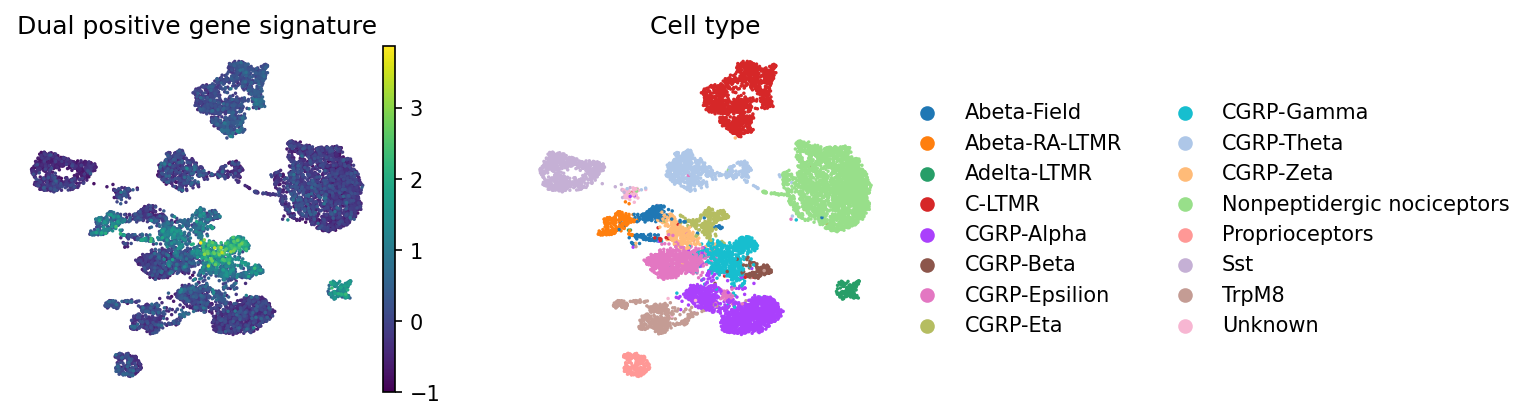

In [ ]:
# Plot score on UMAP
sc.pl.umap(adata, color = ['dual_positive_signature_score', 'original_annotation'], frameon = False, title = ['Dual positive gene signature', 'Cell type'])

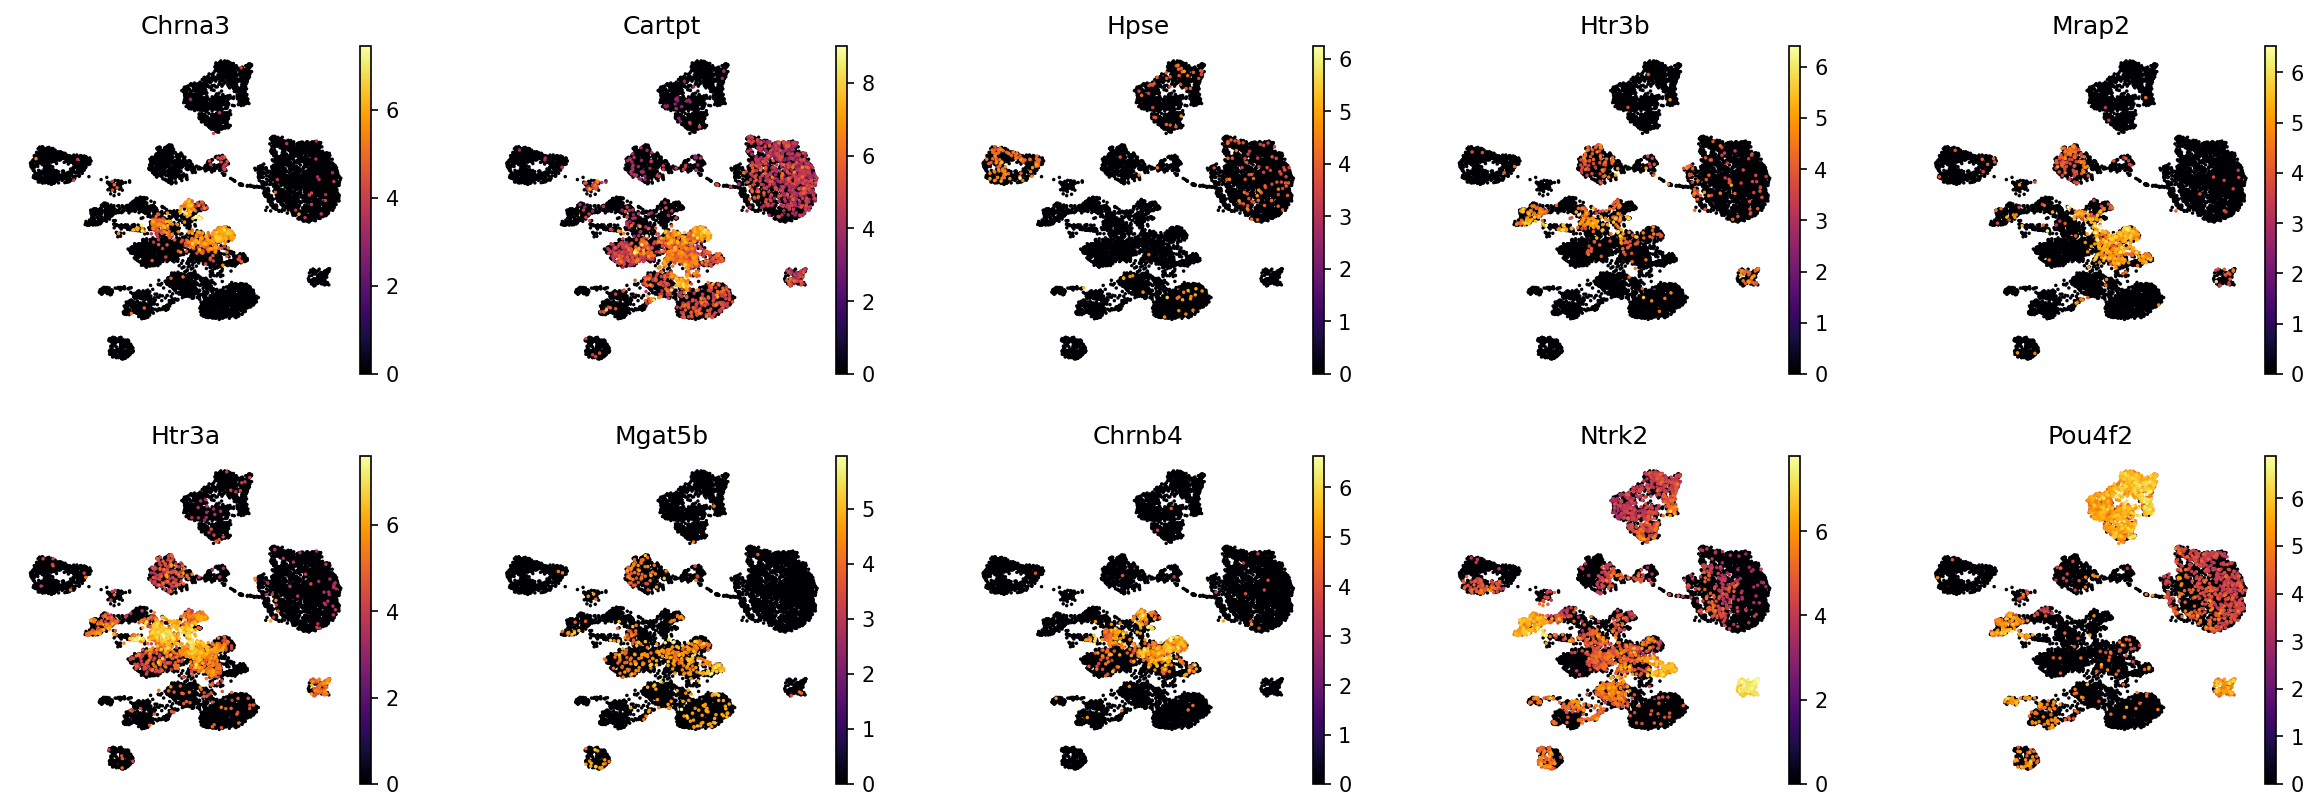

In [ ]:
sc.pl.umap(adata, color = [
    "Chrna3", "Cartpt", "Hpse", "Htr3b", "Mrap2",
    "Htr3a", "Mgat5b", "Chrnb4", "Ntrk2", "Pou4f2"], ncols = 5, cmap = 'inferno', frameon = False, show=False)
plt.savefig(os.path.join(plot_out_dir, "ginty_reference_genes.pdf"), format='pdf', bbox_inches='tight')

/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:928: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/tmp/ipykernel_911/3003100743.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


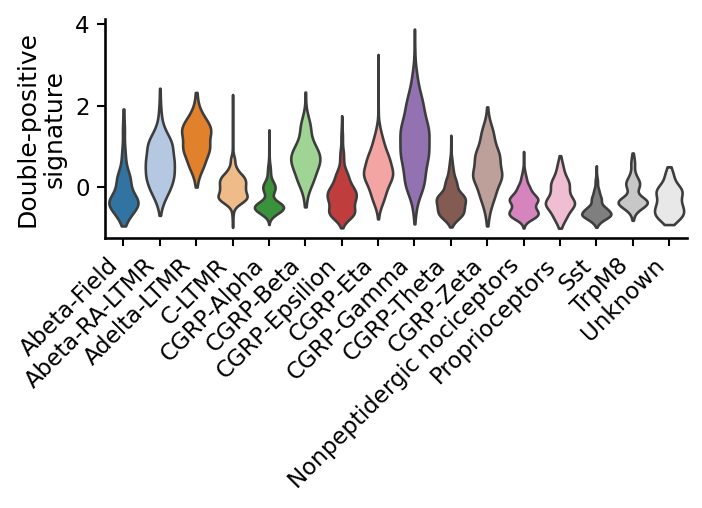

In [ ]:
# Plot violin of signature score by cell type

# ---------------------------
# Minimal clean theme
# ---------------------------
sns.set_theme(style="white")

plt.rcParams['figure.figsize'] = (5, 2)   # <-- ONLY CHANGE (shorter height)
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.bottom'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.labelsize'] = 12

# ---------------------------
# Generate violin without showing
# ---------------------------
ax = sc.pl.violin(
    adata,
    keys='dual_positive_signature_score',
    groupby='original_annotation',
    palette = neuron_label_palette_mapped_ginty,
    stripplot=False,
    jitter=False,
    inner=None,
    show=False
)

# ---------------------------
# Force visible ticks + labels
# ---------------------------
ax.tick_params(
    axis='x',
    which='both',
    bottom=True,
    top=False,
    length=4,
    width=1,
    color='black',
    labelcolor='black'
)

ax.tick_params(
    axis='y',
    which='both',
    left=True,
    right=False,
    length=4,
    width=1,
    color='black',
    labelcolor='black'
)

# ---------------------------
# Fix xtick labels (rotation + color)
# ---------------------------
xticklabels = [t.get_text() for t in ax.get_xticklabels()]
ax.set_xticks(range(len(xticklabels)))
ax.set_xticklabels(
    xticklabels,
    rotation=45,
    ha='right',
    color='black'
)

# ---------------------------
# Labels
# ---------------------------
ax.set_ylabel("Double-positive\nsignature", fontsize=12, color='black')
ax.set_xlabel("")

sns.despine()
plt.tight_layout()
# save
plt.savefig(os.path.join(plot_out_dir, "ginty_reference_signature_violin.pdf"), format='pdf', bbox_inches='tight')

plt.show()

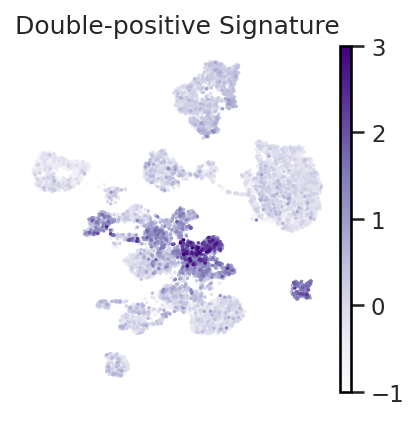

In [ ]:
sc.pl.umap(adata, color = ['dual_positive_signature_score'], frameon = False, title = ['Double-positive Signature'], cmap = 'Purples',
           vmax = 3,
           show=False)
plt.savefig(os.path.join(plot_out_dir, "ginty_reference_doublepositive_signature.pdf"), format='pdf', bbox_inches='tight')